In [20]:
import pandas as pd
import csv
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#  Read CSV
df = pd.read_csv(
    "../data/exports/thesis_data_openAI.csv",
    sep=";",
    quotechar='"',
    quoting=csv.QUOTE_MINIMAL
)

# Clean rows
df = df.dropna(subset=["isNokiaProject"]).copy()

# Convert labels: yes=1, no=0
df["isNokiaProject"] = (
    df["isNokiaProject"]
    .astype(str)
    .str.lower()
    .str.strip()
    .map({"yes": 1, "no": 0})
)

df = df.dropna(subset=["isNokiaProject"]).copy()

# Choose input columns
X = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("") + " " +
    df["evidence"].fillna("")
)

y = df["isNokiaProject"].astype(int)
print(df["isNokiaProject"].value_counts())

# 4. Split into training and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

isNokiaProject
0    83
1    30
Name: count, dtype: int64

Train distribution:
isNokiaProject
0    66
1    24
Name: count, dtype: int64

Test distribution:
isNokiaProject
0    17
1     6
Name: count, dtype: int64


In [21]:
df.head(2)

,title,university,author,date,nokiaScore,link,abstract,isNokiaProject,evidence
0,Smart Chatbot for Discovering Finnish Theses: ...,Metropolia UAS,"Kharel, Suraj",2025,9,https://theseus.fi/handle/10024/901413,This thesis presents a conversational chatbot ...,1,The thesis states it was developed during an i...
1,Defining an Innovative and Interactive Way to ...,Metropolia UAS,"Paunonen, Tomi",2025,5,https://theseus.fi/handle/10024/895247,The objective of this thesis was to explore ho...,0,The text says the thesis explores communicatio...


In [23]:
# Create the model
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words=None,
        ngram_range=(1, 3),
        max_features=20000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
      max_iter=2000,
      class_weight="balanced",
      random_state=42
    ))
])

# Training
model.fit(X_train, y_train)

# Test the model
#Predict with threshold >= 0.5
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.5).astype(int)

# Evaluate
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))



Classification report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91        17
           1       0.80      0.67      0.73         6

    accuracy                           0.87        23
   macro avg       0.84      0.80      0.82        23
weighted avg       0.87      0.87      0.87        23


Confusion matrix:
[[16  1]
 [ 2  4]]


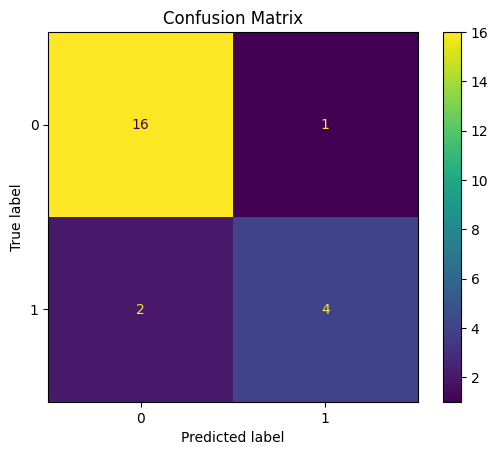

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print("F1 scores:", scores)
print("Mean:", scores.mean())

F1 scores: [0.76923077 0.8        1.         0.66666667 0.28571429]
Mean: 0.7043223443223443


In [26]:
feature_names = model.named_steps["tfidf"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

top = sorted(zip(coefs, feature_names), reverse=True)[:15]

for coef, word in top:
    print(word, coef)

development 0.3432063846044687
network 0.33850668836298203
security 0.3157163903767167
states 0.29788768749823774
application 0.28589360895224325
process 0.24734982413549378
code 0.2445651986016241
developed 0.23589792919002275
team 0.20935361338519706
network as 0.20839012191979453
states it 0.19877599304968627
network as code 0.1959061968615093
as code 0.1959061968615093
testing 0.19487889296353886
test 0.19172855793447088


In [27]:
import joblib

joblib.dump(model, "../data/exports/nokia_thesis_model.pkl")

['../data/exports/nokia_thesis_model.pkl']

### Use the saved model to test tfdf_training_set.csv:

In [29]:
saved_model = joblib.load("../data/exports/nokia_thesis_model.pkl")
df = pd.read_csv(
    "../data/exports/tfidf_training_set.csv",
    sep=None,
    engine="python",
    quotechar='"'
)

df = df.dropna(subset=["target"]).copy()

X = df["text"].fillna("")
y = df["target"].astype(int)

y_pred_all = saved_model.predict(X)

print(classification_report(y, y_pred_all))
print(confusion_matrix(y, y_pred_all))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       1.00      0.88      0.93         8

    accuracy                           0.99       108
   macro avg       1.00      0.94      0.96       108
weighted avg       0.99      0.99      0.99       108

[[100   0]
 [  1   7]]
